## 패키지 다운

In [1]:
import json

path = "deepseek_r1_medicalQA_chatbot원본(모델학습)의_디벨롭_최종.ipynb"

with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

# 'widgets' 메타데이터가 있으면 삭제
if "widgets" in data.get("metadata", {}):
    del data["metadata"]["widgets"]
    print("🧹 Removed broken widgets metadata.")

# 수정된 파일로 덮어쓰기
with open(path, "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

print("Fixed notebook saved:", path)


🧹 Removed broken widgets metadata.
Fixed notebook saved: deepseek_r1_medicalQA_chatbot원본(모델학습)의_디벨롭_최종.ipynb


In [ ]:
%%capture
# installing from PyPI first may reduce the risk of dependency issues.
!pip install -q unsloth # install unsloth. automatically resolve dependencies
!pip install --force-reinstall --no-cache-dir --no-deps git+https://github.com/unslothai/unsloth.git # Also get the latest version Unsloth!

In [ ]:
!pip uninstall -y unsloth trl transformers peft accelerate xformers torchao bitsandbytes torch torchvision torchaudio
!pip cache purge

# (권장) PyTorch 2.3.1 + CUDA 12.1
!pip install --index-url https://download.pytorch.org/whl/cu121 torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1

# Unsloth + 라이브러리 버전 고정
!pip install -U "unsloth[bnb,cu121]" \
  "trl==0.11.3" "transformers==4.44.2" "peft==0.11.1" "accelerate==0.33.0" \
  sentencepiece protobuf huggingface_hub


Found existing installation: transformers 4.57.1
Uninstalling transformers-4.57.1:
  Successfully uninstalled transformers-4.57.1
Found existing installation: peft 0.17.1
Uninstalling peft-0.17.1:
  Successfully uninstalled peft-0.17.1
Found existing installation: accelerate 1.11.0
Uninstalling accelerate-1.11.0:
  Successfully uninstalled accelerate-1.11.0
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
Found existing installation: torch 2.8.0+cu126
Uninstalling torch-2.8.0+cu126:
  Successfully uninstalled torch-2.8.0+cu126
Found existing installation: torchvision 0.23.0+cu126
Uninstalling torchvision-0.23.0+cu126:
  Successfully uninstalled torchvision-0.23.0+cu126
Found existing installation: torchaudio 2.8.0+cu126
Uninstalling torchaudio-2.8.0+cu126:
  Successfully uninstalled torchaudio-2.8.0+cu126
Files removed: 0
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 이 워크스루를 통해 모든 관련 패키지 가져온다.

In [ ]:
!pip install -q datasets trl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 375.8/375.8 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 93.1 MB/s eta 0:00:00


In [ ]:
# Modules for fine-tuning
from unsloth import FastLanguageModel
import torch # Import PyTorch
from trl import SFTTrainer # Trainer for supervised fine-tuning (SFT)
from unsloth import is_bfloat16_supported # Checks if the hardware supports bfloat16 precision
# Hugging Face modules
from huggingface_hub import login # Lets you login to API
from transformers import TrainingArguments # Defines training hyperparameters
from datasets import load_dataset # Lets you load fine-tuning datasets
# Import weights and biases
import wandb

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


🦥 Unsloth Zoo will now patch everything to make training faster!


KeyError: 'align_logprobs_with_mask'

In [ ]:
!git clone https://github.com/ggerganov/llama.cpp
!cd llama.cpp && mkdir -p build && cd build && cmake .. && make -j


Cloning into 'llama.cpp'...
remote: Enumerating objects: 66036, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 66036 (delta 43), reused 22 (delta 22), pack-reused 65963 (from 3)
Receiving objects: 100% (66036/66036), 183.95 MiB | 6.64 MiB/s, done.
Resolving deltas: 100% (48040/48040), done.
-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
CMAKE_BUILD_TYPE=Release
-- Found Git: /usr/bin/git (found version "2.34.1")
-- The ASM compiler identification is GNU
-- Found assembl

## API 키 생성 및 허깅 페이스와 wandb에 로그인하기

In [ ]:
import os
hugging_face_token = "허깅페이스 토큰 입력"  # 너의 Hugging Face 토큰 입력
wnb_token = "완드비 토큰 입력"

In [ ]:
from huggingface_hub import login # Lets you login to API
from transformers import TrainingArguments # Defines training hyperparameters
from datasets import load_dataset # Lets you load fine-tuning datasets
# Import weights and biases
import wandb

In [ ]:
# Initialize Hugging Face & WnB tokens
# # Login to Hugging Face
login(hugging_face_token) # from huggingface_hub import login

# # Login to WnB
wandb.login(key=wnb_token) # import wandb
run = wandb.init(
project='Fine-tune-DeepSeek-R1-Distill-Llama-8B on Medical COT Dataset_YouTube Walkthrough_v2',
job_type="training",
anonymous="allow"
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 20221335 (20221335-sungshin-women-s-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


## 딥시크 R1 토크나이저 로드

In [ ]:
#파라미터 설정
max_seq_length = 2048 # 모델이 처리할 수 있는 최대 시퀀스 길이
dtype = None # 기본 데이터 유형
load_in_4bit = True # 4bit 양자화 활성화 - 메모리 절약 최적화

# DeepSeek R1 모델 및 토크나이저 로드 - unsloth로부터 fastlanguagemodel 가져오기
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/DeepSeek-R1-Distill-Qwen-7B",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit
    token=os.environ.get("hugging_face_token"),
)

==((====))==  Unsloth 2025.9.11: Fast Qwen2 patching. Transformers: 4.56.1.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.161 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 8.9. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.52G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/236 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

Qwen 7B 모델을 L4에 로드한 경우<br>
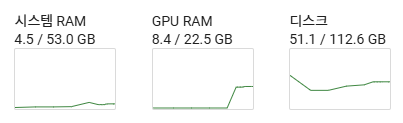

## 파인튜닝 전 의료 데이터로 DeepSeek R1 테스트하기



In [ ]:
# 프롬프트 정
prompt_style = """아래는 특정 작업에 대한 지침과 함께, 추가적인 맥락을 제공하는 입력이 주어져 있습니다.
요청에 적절히 응답하는 답변을 작성하세요.
답변을 작성하기 전에 질문을 신중히 분석하고, 단계적인 사고 과정을 통해 논리적이고 정확한 결론에 도달하세요.

### 지침:
당신은 임상 추론, 진단, 치료 계획에 대해 고도의 전문 지식을 갖춘 의료 전문가입니다.
다음 의학 질문에 대해 **한국어로만** 답변해 주세요.

### 질문:
{}

### 응답:
<think>{}"""


### 모델에서 추론 실행하기


1. 테스트 질문 정의
2. 모델이 논리적 추론 과정을 따르도록 구조화된 프롬프트 사용하여 문제 형식화
3. 입력 토큰화하여 추론 속도 높임
4. 모델 사용하여 응답 생성
5. 출력 토큰을 다시 텍스트로 디코딩

In [ ]:
# 테스트 의료 질문 예시
question = """61세 여성이 기침이나 재채기 같은 활동 중에 발생하는 오랜 요실금 병력이 있으나,
밤에는 누출이 없습니다. 부인과 검사와 Q-tip 테스트를 시행하였습니다.
이러한 소견에 근거할 때, 방광내압검사는 잔뇨량과 배뇨근 수축에 대해 어떤 결과를 보여줄 가능성이 높을까요?"""

# 추론 모드 활성화
FastLanguageModel.for_inference(model)

# 구조화된 프롬프트를 사용하여 질문의 형식을 지정하고 토큰화
inputs = tokenizer([prompt_style.format(question, "")], return_tensors="pt").to("cuda")

# 모델 사용하여 응답 생성
outputs = model.generate(
    input_ids=inputs.input_ids,
    attention_mask=inputs.attention_mask,
    max_new_tokens=1200,
    use_cache=True,
)

# 디코딩
response = tokenizer.batch_decode(outputs)

# 관련 응답 부분(“### 응답:” 뒤)만 추출
print(response[0].split("### 응답:")[1])


<think>
Alright, so I have a 61-year-old woman presenting with chronic dysphoria, specifically during physical activities but not at night. She's also been diagnosed with a gynecomastia, which is a common condition related to the adrenals. The doctor is considering a diagnosis of residual hydramnium syndrome, which is associated with an accumulative hydroxyureauria and can lead to a build-up of fluid in the brain, causing headaches and other symptoms. 

She's had a urinalysis and Q-tip test. The urinalysis might show proteinuria, which is a sign of residual hydramnium syndrome. The Q-tip test is used to detect glucose and ketones in urine, which can indicate ketonuria, a sign of residual hydramnium syndrome. 

The doctor is considering whether to perform an orthopnea (standing orthopnea) test to rule out residual hydramnium syndrome. If the results are positive, it would suggest the presence of residual hydramnium syndrome and possibly a build-up of fluid in the brain. If negative, th

# 모델 시작

In [ ]:
# Updated training prompt style to add </think> tag
train_prompt_style = """아래는 특정 작업에 대한 지침과 함께, 추가적인 맥락을 제공하는 입력이 주어져 있습니다.
요청에 적절히 응답하는 답변을 작성하세요.
답변을 작성하기 전에 질문을 신중히 분석하고, 단계적인 사고 과정을 통해 논리적이고 정확한 결론에 도달하세요.

### 지침:
당신은 임상 추론, 진단, 치료 계획에 대해 고도의 전문 지식을 갖춘 의료 전문가입니다.
다음 의학 질문에 대해 **한국어로만** 답변해 주세요.

### 질문:
{}

### 응답:
<think>
{}
</think>
{}"""


## 데이터 불러오기

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from datasets import Dataset
import json
import re

# 1. 병합된 JSON 경로 지정
json_path = "/content/drive/MyDrive/Colab Notebooks/medical_translated_0000_19700.json"

# 2. JSON 로드
with open(json_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# 3. 한자(중국어)가 포함되었는지 확인하는 함수
def contains_chinese(text):
    return bool(re.search(r'[\u4e00-\u9fff]', text))

# 4. 유효 항목만 골라내고, 중국어 제거
cleaned_data = []
skipped_chinese = 0
skipped_incomplete = 0

for item in data:
    if all(k in item for k in ["Question_ko", "Complex_CoT_ko", "Response_ko"]):
        q, c, r = item["Question_ko"], item["Complex_CoT_ko"], item["Response_ko"]
    elif all(k in item for k in ["Question", "Complex_CoT", "Response"]):
        q, c, r = item["Question"], item["Complex_CoT"], item["Response"]
    else:
        skipped_incomplete += 1
        continue

    # 한자 포함 여부 확인
    if contains_chinese(q) or contains_chinese(c) or contains_chinese(r):
        skipped_chinese += 1
        continue

    cleaned_data.append({
        "Question": q,
        "Complex_CoT": c,
        "Response": r
    })

print(f"✅ 최종 유효한 항목 수: {len(cleaned_data)}")
print(f"🚫 제거된 중국어 포함 항목 수: {skipped_chinese}")
print(f"🚫 키 누락 등으로 제외된 항목 수: {skipped_incomplete}")

# 5. 🤗 Hugging Face Dataset으로 변환
dataset = Dataset.from_list(cleaned_data)


✅ 최종 유효한 항목 수: 18966
🚫 제거된 중국어 포함 항목 수: 192
🚫 키 누락 등으로 제외된 항목 수: 0


In [ ]:
# Show an entry from the dataset
dataset[1]

{'Question': '33세 여성이 드라이버로 가슴을 찔린 지 15분 후 응급실로 후송되었습니다.  맥박 110/분, 호흡 22/분, 혈압 90/65 mmHg의 활력징후와 좌측 겨드랑이 중앙선 8번째 갈비뼈 상연에 깊이 5cm의 자상이 있는 것을 고려할 때, 그녀의 가슴에서 가장 손상되었을 가능성이 높은 해부학적 구조는 무엇입니까?',
 'Complex_CoT': '자, 여기서 무슨 일인지 알아봅시다. 한 여성이 드라이버에 찔린 상처를 입고 왔습니다.  흉부, 왼쪽 8번째 갈비뼈 상연, 겨드랑이 중간선(midaxillary line) 부근입니다.  일단 생각해보면, 폐가 있는 곳과 매우 가깝죠?\n\n먼저 위치부터 이야기해 봅시다.  왼쪽 몸통에 위치하고 있으며, 8번째 갈비뼈 위쪽, 그 부위에는 좌측 폐 하엽과 횡경막 등 중요한 장기들이 많이 있습니다. 드라이버가 얼마나 깊이 들어갔는지 고려하면 횡경막도 포함될 가능성이 있습니다.\n\n상처 깊이는 5cm입니다.  꽤 깊네요. 폐 조직이나 횡경막까지 도달했을 가능성이 분명히 있습니다. 겨드랑이 중간선(midaxillary) 부위라는 점을 고려하면, 좌측 폐 하엽이 있는 영역입니다. 횡경막과 일부 겹칠 가능성도 있지만, 폐가 더 유력해 보입니다.\n\n이제 활력징후가 문제입니다. 심박수가 높고 혈압이 낮습니다. 심각하네요.  제 생각에는 이런 활력징후는 pneumothorax 또는 hemothorax를 의미할 수 있습니다. 폐가 손상되면 두 가지 모두 발생할 수 있으며, 환자는 분명 고통스러울 것이므로 혈압을 떨어뜨리고 심박수를 치솟게 할 수 있습니다.\n\n그러니까, 종합해 보면 가장 의심되는 것은 좌측 폐 하엽입니다. 상처의 깊이와 환자의 상태가 이를 뒷받침합니다.  그리고 이것은 pneumothorax 또는 흉부에 출혈—호흡과 순환에 심각한 문제를 일으킬 수 있는 것들—과 일치합니다.\n\n좋아요, 이를 고려해 볼 때, 가장 손상될 가능성이 높은 것은 폐인 것 같습니다. 상처 위치, 증상, 그리고 전체

## 미세조정 데이터셋 구성

In [ ]:
# We need to format the dataset to fit our prompt training style
EOS_TOKEN = tokenizer.eos_token  # Define EOS_TOKEN which the model when to stop generating text during training
EOS_TOKEN

'<｜end▁of▁sentence｜>'

In [ ]:
# 프롬프트 기능 정의
def formatting_prompts_func(examples):
    inputs = examples["Question"]
    cots = examples["Complex_CoT"]
    outputs = examples["Response"]

    texts = []

    # 데이터 집합을 반복하여 각 질문, 추론 단계 및 응답의 서식을 지정
    for input, cot, output in zip(inputs, cots, outputs):
        text = train_prompt_style.format(input, cot, output) + EOS_TOKEN
        texts.append(text)
    return {
        "text": texts,
    }

In [ ]:
dataset_finetune = dataset.map(formatting_prompts_func, batched = True)
dataset_finetune["text"][0]

Map:   0%|          | 0/18966 [00:00<?, ? examples/s]

"아래는 특정 작업에 대한 지침과 함께, 추가적인 맥락을 제공하는 입력이 주어져 있습니다.\n요청에 적절히 응답하는 답변을 작성하세요.\n답변을 작성하기 전에 질문을 신중히 분석하고, 단계적인 사고 과정을 통해 논리적이고 정확한 결론에 도달하세요.\n\n### 지침:\n당신은 임상 추론, 진단, 치료 계획에 대해 고도의 전문 지식을 갖춘 의료 전문가입니다.\n다음 의학 질문에 대해 **한국어로만** 답변해 주세요.\n\n### 질문:\n왼쪽 팔과 다리의 갑작스러운 약화(sudden weakness), 최근 장거리 여행(recent long-distance travel), 그리고 부어오르고 압통이 있는 오른쪽 아랫다리(swollen and tender right lower leg) 증상을 고려할 때, 이러한 소견을 설명할 수 있는 가장 가능성 높은 특정 심장 이상(cardiac abnormality)은 추가 검사(further evaluation)에서 무엇일까요?\n\n### 응답:\n<think>\nOkay, let's see what's going on here.  환자의 왼쪽 팔과 다리에 갑작스러운 weakness가 나타났습니다 - 이건 신경계 관련 문제, 어쩌면 stroke?을 시사합니다.\n\n하지만, 그게 다가 아닙니다. 오른쪽 아래 다리가 부어오르고 tender합니다. 이건 특히 장시간 비행이나 오랫동안 앉아 있은 후에, deep vein thrombosis를 강하게 의심하게 만드는 증상입니다.\n\n그러니 이제 생각해 봐야 합니다. 다리의 clot이 어떻게 weakness나 stroke 증상 같은 문제를 일으킬 수 있을까요?\n\n아, 맞다! paradoxical embolism이라는 것이 있습니다. 심장에 어떤 종류의 short circuit, 예를 들어 있어서는 안 될 구멍이 있을 경우 발생할 수 있습니다.\n\n정리해 봅시다: 다리의 혈전이 어떻게든 심장의 왼쪽으로 이동하면, 뇌로 이동하여 혈류를 차단하고 그 갑작스러운 weakness를 일으

### LoRA를 사용하여 모델 설정

모든 가중치를 수정하는 대신, **LoRA는 특정 레이어에 훈련 가능한 소형 어댑터**를 추가한다.  
- 이러한 어댑터는 원래 모델을 변경하지 않고 작업별 지식을 **캡쳐**한다.  
- 이를 통해 학습 가능한 파라미터의 수를 90% 이상** 줄여 미세 조정을 **더 빠르고 메모리 효율적으로** 할 수 있다.

In [ ]:
# Apply LoRA
model_lora = FastLanguageModel.get_peft_model(
    model,
    r=8, # 학습 가능한 어댑터의 크기를 결정
    target_modules=[  #  LoRA 어댑터가 적용될 트랜스포머 레이어 목록
        "q_proj",   # Query projection
        "k_proj",   # Key projection
        "v_proj",   # Value projection
        "o_proj",   # Output projection
        "gate_proj",  # Used in feed-forward layers (MLP)
        "up_proj",    # Part of the transformer’s feed-forward network (FFN)
        "down_proj",  # Another part of the transformer’s FFN
    ],
    lora_alpha=8,    # LoRA 업데이트에 대한 스케일링 계수(값이 클수록 LoRA 레이어의 영향력이 커짐)
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,  #등급 안정화 LoRA 사용 여부(여기서는 비활성화되어 고정 등급 LoRA가 사용됨을 의미
    loftq_config=None,  # Low-bit Fine-Tuning Quantization (LoFTQ) 비활성화
)

Unsloth: Already have LoRA adapters! We shall skip this step.


In [ ]:
import types

In [ ]:
# 문제가 되는 부분을 피하기 위한 새로운 `for_training` 메서드 정의
def for_training_patched(self, use_gradient_checkpointing=True):
    """Sets the model to training mode and optionally enables gradient checkpointing."""
    self.train()  # enable training mode

# 새로운 `for_training` 메서드를 `model_lora` 객체에 동적으로 추가
model_lora.for_training = types.MethodType(for_training_patched, model_lora)

Now, we initialize `SFTTrainer`, a supervised fine-tuning trainer from `trl` (Transformer Reinforcement Learning), to fine-tune our model efficiently on a dataset.

In [ ]:
output_dir = "/content/drive/MyDrive/deepseek_outputs"

trainer = SFTTrainer(
    model=model_lora,
    tokenizer=tokenizer,
    train_dataset=dataset_finetune,
    dataset_text_field="text",
    max_seq_length=max_seq_length,
    dataset_num_proc=2,

    # 학습 파라미터 정의
    args=TrainingArguments(
        per_device_train_batch_size=1,
        gradient_accumulation_steps=8,  # 8스텝 동안 gradient를 누적 후 가중치 업데이트
        num_train_epochs=3,
        warmup_steps=5,  # 처음 5스텝 동안 학습률을 점진적으로 증가
        learning_rate=2e-4,
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=10,
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type="linear",
        seed=3407,
        output_dir=output_dir,
        report_to='none',
        save_strategy="steps",
        save_steps=500,                  # 500 step마다 checkpoint 저장
        save_total_limit=3,              # 최근 3개만 유지 (이전 것은 자동 삭제)
    ),
)


Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/18966 [00:00<?, ? examples/s]

## 모델 학습


In [ ]:
from transformers.trainer_utils import get_last_checkpoint
last_checkpoint = get_last_checkpoint(output_dir)
if last_checkpoint is None:
    print(f"[INFO] No checkpoint found. Training will start from scratch.")
else:
    print(f"[INFO] Found checkpoint {last_checkpoint}. Resuming training from it.")

[INFO] Found checkpoint /content/drive/MyDrive/deepseek_outputs/checkpoint-7000. Resuming training from it.


In [ ]:
# Start the fine-tuning process
trainer_stats = trainer.train(resume_from_checkpoint=False)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 18,966 | Num Epochs = 3 | Total steps = 7,113
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 20,185,088 of 7,635,801,600 (0.26% trained)


Step,Training Loss
10,3.152900
20,2.624700
30,2.256300
40,2.051000
50,1.918500
60,1.905100
70,1.862300
80,1.799500
90,1.773600
100,1.678300


Step,Training Loss
10,3.152900
20,2.624700
30,2.256300
40,2.051000
50,1.918500
60,1.905100
70,1.862300
80,1.799500
90,1.773600
100,1.678300


In [ ]:
trainer_stats = trainer.train(resume_from_checkpoint=last_checkpoint)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 18,966 | Num Epochs = 3 | Total steps = 7,113
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 20,185,088 of 7,635,801,600 (0.26% trained)


Step,Training Loss
4010,1.167500
4020,1.164800
4030,1.197800
4040,1.209700
4050,1.135500
4060,1.185700
4070,1.143900
4080,1.189000
4090,1.180800
4100,1.188700


In [ ]:
trainer_stats = trainer.train(resume_from_checkpoint=last_checkpoint)

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 18,966 | Num Epochs = 3 | Total steps = 7,113
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 20,185,088 of 7,635,801,600 (0.26% trained)


Step,Training Loss
7010,1.100800
7020,1.038000
7030,1.075700
7040,1.084400
7050,1.052200
7060,1.087900
7070,1.052800
7080,1.049100
7090,1.063500
7100,1.090300


In [ ]:
trainer_stats

TrainOutput(global_step=7112, training_loss=0.016973028602696644, metrics={'train_runtime': 707.2588, 'train_samples_per_second': 80.449, 'train_steps_per_second': 10.057, 'total_flos': 2.297828445816573e+18, 'train_loss': 0.016973028602696644, 'epoch': 2.999683644416324})

In [ ]:
model_lora

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(152064, 3584, padding_idx=151654)
        (layers): ModuleList(
          (0-3): 4 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=3584, out_features=3584, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3584, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=3584, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear(
   

In [ ]:
model_lora.push_to_hub("nanyaas/deepseek-r1-medicalQA-Qwen_7B_dev") # Online saving
tokenizer.push_to_hub("nanyaas/deepseek-r1-medicalQA-Qwen_7B_dev") # Online saving

README.md:   0%|          | 0.00/624 [00:00<?, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 45.5kB / 80.8MB            

Saved model to https://huggingface.co/nanyaas/deepseek-r1-medicalQA-Qwen_7B_dev


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpmetaqjrm/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

In [ ]:
new_model_name = "nanyaas/deepseek-r1-medicalQA-Qwen_7B_dev"
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = new_model_name, # YOUR MODEL YOU USED FOR TRAINING
    max_seq_length = 2048,
    dtype = None,
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model);

==((====))==  Unsloth 2025.9.11: Fast Qwen2 patching. Transformers: 4.56.1.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.161 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 8.9. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.52G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/80.8M [00:00<?, ?B/s]

Unsloth 2025.9.11 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


In [ ]:
from huggingface_hub import snapshot_download
local_dir = "/content/hf_model"
snapshot_download(
    repo_id="nanyaas/deepseek-r1-medicalQA-Qwen_7B_dev",
    local_dir=local_dir,
    local_dir_use_symlinks=False,
)
import os
print(os.listdir(local_dir)[:15])  # 여기서 config.json / tokenizer.* / model*.safetensors 보이면 OK


.gitattributes: 0.00B [00:00, ?B/s]

README.md:   0%|          | 0.00/624 [00:00<?, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/80.8M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

['chat_template.jinja', 'tokenizer.json', 'tokenizer_config.json', 'adapter_config.json', '.cache', 'README.md', 'special_tokens_map.json', '.gitattributes', 'adapter_model.safetensors']


##모델 불러오기 & 병합

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
import os

BASE_REPO  = "unsloth/DeepSeek-R1-Distill-Qwen-7B"          # 실제 베이스
LORA_REPO  = "nanyaas/deepseek-r1-medicalQA-Qwen_7B_dev"    # LoRA 어댑터
MERGED_DIR = "/content/merged-hf"

tok  = AutoTokenizer.from_pretrained(BASE_REPO, use_fast=True)
base = AutoModelForCausalLM.from_pretrained(BASE_REPO, torch_dtype="auto", device_map="cpu")

lora = PeftModel.from_pretrained(base, LORA_REPO)
merged = lora.merge_and_unload()

# 병합된 모델 저장
os.makedirs(MERGED_DIR, exist_ok=True)
merged.save_pretrained(MERGED_DIR, safe_serialization=True)
tok.save_pretrained(MERGED_DIR)

print(os.listdir(MERGED_DIR))


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/822 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


...

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/236 [00:00<?, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/80.8M [00:00<?, ?B/s]

['model-00004-of-00004.safetensors', 'chat_template.jinja', 'tokenizer.json', 'tokenizer_config.json', 'model-00001-of-00004.safetensors', 'generation_config.json', 'special_tokens_map.json', 'config.json', 'model-00003-of-00004.safetensors', 'model-00002-of-00004.safetensors', 'model.safetensors.index.json']


In [ ]:
# llama.cpp 변환 스크립트 다운로드
!curl -L https://raw.githubusercontent.com/ggerganov/llama.cpp/refs/heads/master/convert-hf-to-gguf.py \
  -o /content/llama.cpp/convert-hf-to-gguf.py

# 잘 받았는지 확인
!ls -l /content/llama.cpp/convert-hf-to-gguf.py


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    14  100    14    0     0     42      0 --:--:-- --:--:-- --:--:--    42
-rw-r--r-- 1 root root 14 Oct 30 07:49 /content/llama.cpp/convert-hf-to-gguf.py


## HF -> GGUF 변환

In [ ]:
!python /content/llama.cpp/convert-hf-to-gguf.py /content/merged-hf \
  --outfile /content/model-f16.gguf \
  --outtype f16


INFO:hf-to-gguf:Loading model: merged-hf
INFO:hf-to-gguf:Model architecture: Qwen2ForCausalLM
INFO:hf-to-gguf:gguf: loading model weight map from 'model.safetensors.index.json'
INFO:hf-to-gguf:gguf: indexing model part 'model-00001-of-00004.safetensors'
INFO:hf-to-gguf:gguf: indexing model part 'model-00002-of-00004.safetensors'
INFO:hf-to-gguf:gguf: indexing model part 'model-00003-of-00004.safetensors'
INFO:hf-to-gguf:gguf: indexing model part 'model-00004-of-00004.safetensors'
INFO:gguf.gguf_writer:gguf: This GGUF file is for Little Endian only
INFO:hf-to-gguf:Exporting model...
INFO:hf-to-gguf:token_embd.weight,         torch.bfloat16 --> F16, shape = {3584, 152064}
INFO:hf-to-gguf:blk.0.attn_norm.weight,    torch.bfloat16 --> F32, shape = {3584}
INFO:hf-to-gguf:blk.0.ffn_down.weight,     torch.bfloat16 --> F16, shape = {18944, 3584}
INFO:hf-to-gguf:blk.0.ffn_gate.weight,     torch.bfloat16 --> F16, shape = {3584, 18944}
INFO:hf-to-gguf:blk.0.ffn_up.weight,       torch.bfloat16 -->

In [ ]:
%%bash
set -e
if [ -x /content/llama.cpp/build/bin/llama-quantize ]; then
  echo /content/llama.cpp/build/bin/llama-quantize > /content/qbin_path.txt
elif [ -x /content/llama.cpp/build/bin/quantize ]; then
  echo /content/llama.cpp/build/bin/quantize > /content/qbin_path.txt
else
  echo "❌ quantize 바이너리를 찾지 못했습니다. llama.cpp 빌드를 다시 확인하세요." >&2
  exit 1
fi
echo "✅ Saved quantizer path: $(cat /content/qbin_path.txt)"


✅ Saved quantizer path: /content/llama.cpp/build/bin/llama-quantize


## 양자화

In [ ]:
%%bash
set -e
QBIN="$(cat /content/qbin_path.txt)"
test -f /content/model-f16.gguf || { echo "❌ /content/model-f16.gguf 없음(변환 전 단계 확인)"; exit 1; }
echo "➡️ Running: $QBIN /content/model-f16.gguf /content/model-q4_k_m.gguf q4_k_m"
"$QBIN" /content/model-f16.gguf /content/model-q4_k_m.gguf q4_k_m
ls -lh /content/model-*.gguf


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
dst_dir = "/content/drive/MyDrive/deepseek/medicalQA-gguf-Qwen-en"
os.makedirs(dst_dir, exist_ok=True)
src = "/content/model-q4_k_m.gguf"
dst = os.path.join(dst_dir, "medicalQA-q4_k_m.gguf")
shutil.copy2(src, dst)
print("✅ Saved to:", dst)


Mounted at /content/drive
✅ Saved to: /content/drive/MyDrive/deepseek/medicalQA-gguf-Qwen-en/medicalQA-q4_k_m.gguf


In [ ]:
!pip -q install huggingface_hub

from huggingface_hub import HfApi, create_repo, login
from textwrap import dedent
import os

# 1) 로그인 (이미 했다면 건너뜀)
login()  # 토큰 입력

# 2) 리포 지정 (원하는 이름으로 변경)
repo_id = "nanyaas/medicalQA-DeepSeekR1-Qwen7B-GGUF_2"

# 3) 리포 생성(있으면 통과)
api = HfApi()
create_repo(repo_id=repo_id, repo_type="model", private=False, exist_ok=True)

# 4) README(선택)
readme = dedent(f"""
# {repo_id}

Merged **unsloth/DeepSeek-R1-Distill-Qwen-7B** with **nanyaas/deepseek-r1-medicalQA-Qwen_7B_dev**, then converted to **GGUF** (q4_k_m).

- Base: `unsloth/DeepSeek-R1-Distill-Qwen-7B`
- LoRA: `nanyaas/deepseek-r1-medicalQA-Qwen_7B_dev`
- Format: GGUF (q4_k_m)

## llama.cpp
```bash
./llama-cli -m model-q4_k_m.gguf -p "<|im_start|>system
한국어로만 답하세요.
<|im_end|><|im_start|>user
간단 자기소개.
<|im_end|><|im_start|>assistant
"
""")

with open("/content/README.md","w") as f:
  f.write(readme)
  print("✅ README.md 생성 완료!")


✅ README.md 생성 완료!


In [ ]:
# 허깅페이스 업로드
api.upload_file(
    path_or_fileobj="/content/model-q4_k_m.gguf",
    path_in_repo="model-q4_k_m.gguf",
    repo_id="nanyaas/medicalQA-DeepSeekR1-Qwen7B-GGUF_2"
)

api.upload_file(
    path_or_fileobj="/content/README.md",
    path_in_repo="README.md",
    repo_id="nanyaas/medicalQA-DeepSeekR1-Qwen7B-GGUF_2"
)

print("🚀 HuggingFace 업로드 완료!")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /content/model-q4_k_m.gguf  :   1%|          | 33.6MB / 4.68GB            

🚀 HuggingFace 업로드 완료!


In [ ]:
!huggingface-cli repo files nanyaas/medicalQA-DeepSeekR1-Qwen7B-GGUF_2

usage: huggingface-cli <command> [<args>] repo [-h] {create} ...
huggingface-cli <command> [<args>] repo: error: argument {create}: invalid choice: 'files' (choose from create)


##모델 출력 예시

In [ ]:
# 0) 경로와 질문 세팅
GGUF_PATH = "/content/drive/MyDrive/deepseek/medicalQA-gguf-Qwen-en/medicalQA-q4_k_m.gguf"
QUESTION = """61세 여성이 기침/재채기 같은 활동 중에 생기는 요실금이 오래되었고, 야간 누출은 없습니다.
부인과 검사와 Q-tip test 후, 방광내압검사에서 잔뇨량과 배뇨근 수축은 어떻게 나올 가능성이 높을까요?"""

import os
assert os.path.exists(GGUF_PATH), f"GGUF not found: {GGUF_PATH}"

from llama_cpp import Llama

# 2) 모델 로드
llm = Llama(
    model_path=GGUF_PATH,
    n_gpu_layers=-1,
    n_ctx=4096,
    verbose=False,
)


arch = (llm.metadata or {}).get("general.architecture", "").lower()
chat_format = "qwen2" if "qwen" in arch else None

def chat(messages):
    if hasattr(llm, "create_chat_completion") and chat_format == "qwen2":
        return llm.create_chat_completion(
            messages=messages,
            temperature=0.7,
            top_p=0.9,
            max_tokens=800,
        )["choices"][0]["message"]["content"]
    else:
        # 일반 프롬프트(시스템/유저를 직접 포맷)
        prompt = (
            "You are a medical expert. Answer in Korean. "
            "Explain briefly and clearly. If model emits <think>…</think>, do not include it in final answer.\n\n"
            f"Question:\n{QUESTION}\n\nAnswer:"
        )
        out = llm(
            prompt=prompt,
            max_tokens=800,
            temperature=0.7,
            top_p=0.9,
        )["choices"][0]["text"]
        return out

# 3) Qwen 형식 메시지(아키텍처가 qwen일 때)
qwen_messages = [
    {"role": "system", "content": "You are a medical expert. Answer in Korean briefly and clearly."},
    {"role": "user",   "content": QUESTION},
]

# 4) 추론 실행
answer = chat(qwen_messages)
print(answer.strip())


ERROR: Could not find a version that satisfies the requirement llama-cpp-python-cu124 (from versions: none)
ERROR: No matching distribution found for llama-cpp-python-cu124


llama_context: n_ctx_per_seq (4096) < n_ctx_train (131072) -- the full capacity of the model will not be utilized


61세 여성 환자가 요실금을 호소하고 있습니다. 기침이나 재채기 같은 활동을 할 때 발생한다고 합니다. 이는 요폐를 시사합니다.  소변을 제대로 배출할 수 없을 때, 특히 배뇨 시 발생하는 문제입니다.

소변 배출 시 문제를 일으킬 수 있는 원인에 대해 생각해 봅시다. 방광 내압 검사 결과는 어떨까요? 방광이 완전히 비워지지 않은 상태일 가능성이 높습니다. 즉, 요폐로 인해 완전한 잔뇨가 발생했을 가능성이 높습니다.

이제 배뇨근 수축에 대해 이야기해 봅시다. 배뇨근의 수축은 소변 배출에 매우 중요한 역할을 합니다. 신체가 이러한 수축을 통해 방광을 제대로 수축하는 것을 기대할 수 있지만, 요폐로 인해 방광이 완전히 비워지지 않으면 이러한 수축이 충분하지 않을 수 있습니다. 따라서 방광이 완전히 비워지지 않으면 수축도 불충분할 수 있습니다.

그리고 야간 누출은 없습니다. 이는 야간 배뇨 문제를 배제하는 중요한 징후입니다. 야간 누출은 요폐를 시사하지만, 야간 누출이 없다는 것은 저를 다른 방향으로 생각하게 합니다.

결론적으로, 방광이 완전히 비워지지 않게 되어 요폐를 일으키고, 수축이 충분하지 않을 가능성이 높아 방광 수축이 부족한 것입니다.  이로써 요폐의 일반적인 원인, 즉 방광 비대사가 설명됩니다.  전형적인 요폐 사례입니다.

따라서 요폐라면, 방광 내압 검사에서 완전한 잔뇨와 수축 부족이 나타날 것으로 예상합니다.
</think>

61세 여성 환자의 요실금은 방광 비대사로 인해 발생할 가능성이 높습니다. 방광 내압 검사에서는 잔뇨량이 낮지 않은 것을 보일 수 있는데, 이는 방광이 완전히 비워지지 않았다는 것을 의미합니다.  또한, 방광근 수축이 부족할 가능성이 높습니다. 이는 방광이 완전히 비워지지 않아 소변 배출을 돕는 신호를 전달하는 수축이 부족하기 때문입니다.
